# LNG Liquefaction Processes

This notebook demonstrates simulation of LNG liquefaction processes using NeqSim.
We cover three main cycle types:

1. **Single Mixed Refrigerant (SMR)** — Simple cycle using a multi-component refrigerant
2. **Propane Pre-Cooled Mixed Refrigerant (C3MR)** — Two-loop cycle with propane pre-cooling
3. **Nitrogen Expander Cycle** — Turboexpander-based cycle using pure nitrogen

Each cycle is modeled as a complete process flowsheet with compressors, coolers, valves,
heat exchangers, and separators.

## Background

LNG liquefaction cools natural gas from ambient temperature (~25°C) down to approximately
-162°C at near-atmospheric pressure. The choice of cycle depends on plant capacity,
efficiency requirements, and equipment constraints.

| Cycle | Typical Capacity | Specific Power | Complexity |
|-------|-----------------|----------------|------------|
| SMR | 0.5–2 MTPA | 0.35–0.40 kWh/kg LNG | Low |
| C3MR | 3–8 MTPA | 0.30–0.35 kWh/kg LNG | Medium |
| N₂ Expander | 0.5–1.5 MTPA | 0.45–0.55 kWh/kg LNG | Low |

In [1]:
# Setup NeqSim
import subprocess, sys
try:
    from neqsim import jneqsim
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'neqsim'])
    from neqsim import jneqsim

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# NeqSim Java classes
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Separator = jneqsim.process.equipment.separator.Separator
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

print('NeqSim loaded successfully')

NeqSim loaded successfully


## 1. Single Mixed Refrigerant (SMR) Cycle

The SMR cycle uses a single multi-component refrigerant (methane, ethane, propane, nitrogen)
to provide cooling across the entire temperature range. The refrigerant is compressed,
after-cooled, expanded through a JT valve, and evaporated against the natural gas feed
in a multi-stream heat exchanger.

### Process Flow:
1. Natural gas feed is pre-cooled and liquefied in the cryogenic heat exchanger
2. Mixed refrigerant is compressed in two stages with intercooling
3. Compressed MR is cooled and partially condensed
4. MR is expanded through a JT valve
5. Cold two-phase MR provides cooling in the main heat exchanger

In [2]:
# --- Define Natural Gas Feed ---
ng_fluid = SystemSrkEos(273.15 + 25.0, 60.0)
ng_fluid.addComponent('nitrogen', 0.5)
ng_fluid.addComponent('methane', 89.0)
ng_fluid.addComponent('ethane', 6.5)
ng_fluid.addComponent('propane', 2.5)
ng_fluid.addComponent('i-butane', 0.7)
ng_fluid.addComponent('n-butane', 0.8)
ng_fluid.setMixingRule('classic')

ng_feed = Stream('NG Feed', ng_fluid)
ng_feed.setFlowRate(100000.0, 'kg/hr')  # ~100 t/h ≈ 0.8 MTPA
ng_feed.setTemperature(25.0, 'C')
ng_feed.setPressure(60.0, 'bara')

# --- Define Mixed Refrigerant ---
mr_fluid = SystemSrkEos(273.15 - 40.0, 3.0)
mr_fluid.addComponent('nitrogen', 5.0)
mr_fluid.addComponent('methane', 40.0)
mr_fluid.addComponent('ethane', 35.0)
mr_fluid.addComponent('propane', 20.0)
mr_fluid.setMixingRule('classic')

mr_feed = Stream('MR Low P', mr_fluid)
mr_feed.setFlowRate(180000.0, 'kg/hr')
mr_feed.setTemperature(-40.0, 'C')
mr_feed.setPressure(3.0, 'bara')

# --- Build SMR Process ---
smr_process = ProcessSystem()
smr_process.add(ng_feed)
smr_process.add(mr_feed)

# MR Compression - Stage 1
mr_comp1 = Compressor('MR Comp 1', mr_feed)
mr_comp1.setOutletPressure(10.0)
mr_comp1.setIsentropicEfficiency(0.75)
smr_process.add(mr_comp1)

# Intercooler
mr_ic = Cooler('MR Intercooler', mr_comp1.getOutletStream())
mr_ic.setOutTemperature(273.15 + 30.0)
smr_process.add(mr_ic)

# MR Compression - Stage 2
mr_comp2 = Compressor('MR Comp 2', mr_ic.getOutletStream())
mr_comp2.setOutletPressure(30.0)
mr_comp2.setIsentropicEfficiency(0.75)
smr_process.add(mr_comp2)

# Aftercooler
mr_ac = Cooler('MR Aftercooler', mr_comp2.getOutletStream())
mr_ac.setOutTemperature(273.15 + 30.0)
smr_process.add(mr_ac)

# MR JT Valve - expand to low pressure
mr_jt = ThrottlingValve('MR JT Valve', mr_ac.getOutletStream())
mr_jt.setOutletPressure(3.0)
smr_process.add(mr_jt)

# Main Cryogenic Heat Exchanger (MR cold side cools NG)
main_hx = HeatExchanger('Main Cryo HX', ng_feed, mr_jt.getOutletStream())
main_hx.setUAvalue(500000.0)
smr_process.add(main_hx)

# Final NG letdown valve to near-atmospheric
lng_valve = ThrottlingValve('LNG Letdown', main_hx.getOutStream(0))
lng_valve.setOutletPressure(1.2)
smr_process.add(lng_valve)

# Run the process
smr_process.run()

print('=== SMR Cycle Results ===')
print(f'NG Feed Temperature:    {ng_feed.getTemperature() - 273.15:.1f} °C')
print(f'NG After Main HX:       {main_hx.getOutStream(0).getTemperature() - 273.15:.1f} °C')
print(f'LNG Product Temperature:{lng_valve.getOutletStream().getTemperature() - 273.15:.1f} °C')
print(f'LNG Product Pressure:   {lng_valve.getOutletStream().getPressure("bara"):.1f} bara')
print()
print(f'MR after JT Valve:      {mr_jt.getOutletStream().getTemperature() - 273.15:.1f} °C')
print(f'MR Comp 1 Power:        {mr_comp1.getPower("kW"):.0f} kW')
print(f'MR Comp 2 Power:        {mr_comp2.getPower("kW"):.0f} kW')
total_power = mr_comp1.getPower('kW') + mr_comp2.getPower('kW')
print(f'Total Compression Power:{total_power:.0f} kW')
print(f'Specific Power:         {total_power / (100000.0):.3f} kWh/kg LNG')

=== SMR Cycle Results ===
NG Feed Temperature:    25.0 °C
NG After Main HX:       5.8 °C
LNG Product Temperature:-35.2 °C
LNG Product Pressure:   1.2 bara

MR after JT Valve:      4.2 °C
MR Comp 1 Power:        6162 kW
MR Comp 2 Power:        7011 kW
Total Compression Power:13173 kW
Specific Power:         0.132 kWh/kg LNG


## 2. Propane Pre-Cooled Mixed Refrigerant (C3MR)

The C3MR process uses a propane refrigeration loop for pre-cooling the natural gas
to approximately -35°C, followed by a mixed refrigerant loop for sub-cooling and
liquefaction down to -162°C.

### Propane Loop
Uses three pressure levels (high, medium, low) for efficient pre-cooling.

### MR Loop
After pre-cooling, the MR loop handles the final liquefaction.

In [3]:
# --- C3MR Process: Propane Pre-cooling Loop ---

# Natural gas feed
ng_fluid2 = SystemSrkEos(273.15 + 30.0, 65.0)
ng_fluid2.addComponent('nitrogen', 0.5)
ng_fluid2.addComponent('methane', 89.0)
ng_fluid2.addComponent('ethane', 6.5)
ng_fluid2.addComponent('propane', 2.5)
ng_fluid2.addComponent('i-butane', 0.7)
ng_fluid2.addComponent('n-butane', 0.8)
ng_fluid2.setMixingRule('classic')

ng_feed2 = Stream('NG Feed C3MR', ng_fluid2)
ng_feed2.setFlowRate(200000.0, 'kg/hr')  # ~200 t/h ≈ 1.6 MTPA
ng_feed2.setTemperature(30.0, 'C')
ng_feed2.setPressure(65.0, 'bara')

# Propane refrigerant stream (liquid propane at high pressure)
c3_fluid = SystemSrkEos(273.15 + 35.0, 15.0)
c3_fluid.addComponent('propane', 1.0)
c3_fluid.setMixingRule('classic')

c3_feed = Stream('C3 HP Liquid', c3_fluid)
c3_feed.setFlowRate(300000.0, 'kg/hr')
c3_feed.setTemperature(35.0, 'C')
c3_feed.setPressure(15.0, 'bara')

c3mr_process = ProcessSystem()
c3mr_process.add(ng_feed2)
c3mr_process.add(c3_feed)

# Pre-cooling: Cool NG with propane (simulated as cooler setting target temperature)
# Stage 1: Cool to +5°C
ng_precool1 = Cooler('NG Precool 1', ng_feed2)
ng_precool1.setOutTemperature(273.15 + 5.0)
c3mr_process.add(ng_precool1)

# Stage 2: Cool to -15°C
ng_precool2 = Cooler('NG Precool 2', ng_precool1.getOutletStream())
ng_precool2.setOutTemperature(273.15 - 15.0)
c3mr_process.add(ng_precool2)

# Stage 3: Cool to -33°C
ng_precool3 = Cooler('NG Precool 3', ng_precool2.getOutletStream())
ng_precool3.setOutTemperature(273.15 - 33.0)
c3mr_process.add(ng_precool3)

# --- Propane Compression Train ---
# Propane JT valve (expand liquid propane to provide cooling)
c3_jt = ThrottlingValve('C3 JT Valve', c3_feed)
c3_jt.setOutletPressure(1.5)  # low pressure propane ~-42°C
c3mr_process.add(c3_jt)

# Propane evaporates (simulated as heater to suction conditions)
c3_evap = Heater('C3 Evaporator', c3_jt.getOutletStream())
c3_evap.setOutTemperature(273.15 - 35.0)
c3mr_process.add(c3_evap)

# Propane compressor
c3_comp = Compressor('C3 Compressor', c3_evap.getOutletStream())
c3_comp.setOutletPressure(15.0)
c3_comp.setIsentropicEfficiency(0.78)
c3mr_process.add(c3_comp)

# Propane aftercooler/condenser
c3_cond = Cooler('C3 Condenser', c3_comp.getOutletStream())
c3_cond.setOutTemperature(273.15 + 35.0)
c3mr_process.add(c3_cond)

# --- MR Loop for Liquefaction ---
mr_fluid2 = SystemSrkEos(273.15 - 33.0, 4.0)
mr_fluid2.addComponent('nitrogen', 5.0)
mr_fluid2.addComponent('methane', 45.0)
mr_fluid2.addComponent('ethane', 35.0)
mr_fluid2.addComponent('propane', 15.0)
mr_fluid2.setMixingRule('classic')

mr_feed2 = Stream('MR Return', mr_fluid2)
mr_feed2.setFlowRate(350000.0, 'kg/hr')
mr_feed2.setTemperature(-33.0, 'C')
mr_feed2.setPressure(4.0, 'bara')
c3mr_process.add(mr_feed2)

# MR compression (two stages)
mr2_comp1 = Compressor('MR Comp 1 C3MR', mr_feed2)
mr2_comp1.setOutletPressure(15.0)
mr2_comp1.setIsentropicEfficiency(0.75)
c3mr_process.add(mr2_comp1)

mr2_ic = Cooler('MR IC C3MR', mr2_comp1.getOutletStream())
mr2_ic.setOutTemperature(273.15 + 30.0)
c3mr_process.add(mr2_ic)

mr2_comp2 = Compressor('MR Comp 2 C3MR', mr2_ic.getOutletStream())
mr2_comp2.setOutletPressure(45.0)
mr2_comp2.setIsentropicEfficiency(0.75)
c3mr_process.add(mr2_comp2)

mr2_ac = Cooler('MR AC C3MR', mr2_comp2.getOutletStream())
mr2_ac.setOutTemperature(273.15 + 30.0)
c3mr_process.add(mr2_ac)

# MR pre-cooled by propane to -33°C
mr2_precool = Cooler('MR Precool', mr2_ac.getOutletStream())
mr2_precool.setOutTemperature(273.15 - 33.0)
c3mr_process.add(mr2_precool)

# MR JT valve
mr2_jt = ThrottlingValve('MR JT C3MR', mr2_precool.getOutletStream())
mr2_jt.setOutletPressure(4.0)
c3mr_process.add(mr2_jt)

# Main cryogenic HX: pre-cooled NG vs MR
main_hx2 = HeatExchanger('Main Cryo HX C3MR', ng_precool3.getOutletStream(), mr2_jt.getOutletStream())
main_hx2.setUAvalue(800000.0)
c3mr_process.add(main_hx2)

# LNG letdown
lng_valve2 = ThrottlingValve('LNG Letdown C3MR', main_hx2.getOutStream(0))
lng_valve2.setOutletPressure(1.2)
c3mr_process.add(lng_valve2)

c3mr_process.run()

print('=== C3MR Cycle Results ===')
print(f'NG Feed:                {ng_feed2.getTemperature() - 273.15:.1f} °C')
print(f'After Precool 1:        {ng_precool1.getOutletStream().getTemperature() - 273.15:.1f} °C')
print(f'After Precool 2:        {ng_precool2.getOutletStream().getTemperature() - 273.15:.1f} °C')
print(f'After Precool 3:        {ng_precool3.getOutletStream().getTemperature() - 273.15:.1f} °C')
print(f'LNG Product Temp:       {lng_valve2.getOutletStream().getTemperature() - 273.15:.1f} °C')
print()
c3_power = c3_comp.getPower('kW')
mr2_power = mr2_comp1.getPower('kW') + mr2_comp2.getPower('kW')
total_c3mr = c3_power + mr2_power
print(f'Propane Comp Power:     {c3_power:.0f} kW')
print(f'MR Comp Total Power:    {mr2_power:.0f} kW')
print(f'Total Power:            {total_c3mr:.0f} kW')
print(f'Specific Power:         {total_c3mr / 200000.0:.3f} kWh/kg LNG')

=== C3MR Cycle Results ===
NG Feed:                30.0 °C
After Precool 1:        5.0 °C
After Precool 2:        -15.0 °C
After Precool 3:        -33.0 °C
LNG Product Temp:       -153.5 °C

Propane Comp Power:     266 kW
MR Comp Total Power:    28616 kW
Total Power:            28882 kW
Specific Power:         0.144 kWh/kg LNG


## 3. Nitrogen Expander Cycle

The nitrogen expander cycle uses pure nitrogen as a refrigerant. Nitrogen is compressed,
after-cooled, then expanded through a turboexpander, producing cold gas that cools
the natural gas feed against it. This cycle is simple, safe (inert refrigerant),
and suitable for offshore or small-scale LNG.

In [4]:
# --- Nitrogen Expander Cycle ---
Expander = jneqsim.process.equipment.expander.Expander

# Natural gas feed
ng_fluid3 = SystemSrkEos(273.15 + 25.0, 60.0)
ng_fluid3.addComponent('nitrogen', 0.5)
ng_fluid3.addComponent('methane', 90.0)
ng_fluid3.addComponent('ethane', 6.0)
ng_fluid3.addComponent('propane', 2.5)
ng_fluid3.addComponent('n-butane', 1.0)
ng_fluid3.setMixingRule('classic')

ng_feed3 = Stream('NG Feed N2', ng_fluid3)
ng_feed3.setFlowRate(80000.0, 'kg/hr')  # ~80 t/h
ng_feed3.setTemperature(25.0, 'C')
ng_feed3.setPressure(60.0, 'bara')

# Nitrogen stream (returning from HX, warm and low-pressure)
n2_fluid = SystemSrkEos(273.15 + 15.0, 8.0)
n2_fluid.addComponent('nitrogen', 1.0)
n2_fluid.setMixingRule('classic')

n2_return = Stream('N2 Return', n2_fluid)
n2_return.setFlowRate(400000.0, 'kg/hr')  # Large N2 circulation
n2_return.setTemperature(15.0, 'C')
n2_return.setPressure(8.0, 'bara')

n2_process = ProcessSystem()
n2_process.add(ng_feed3)
n2_process.add(n2_return)

# N2 Compression Stage 1
n2_comp1 = Compressor('N2 Comp 1', n2_return)
n2_comp1.setOutletPressure(25.0)
n2_comp1.setIsentropicEfficiency(0.80)
n2_process.add(n2_comp1)

n2_ic = Cooler('N2 IC', n2_comp1.getOutletStream())
n2_ic.setOutTemperature(273.15 + 30.0)
n2_process.add(n2_ic)

# N2 Compression Stage 2
n2_comp2 = Compressor('N2 Comp 2', n2_ic.getOutletStream())
n2_comp2.setOutletPressure(55.0)
n2_comp2.setIsentropicEfficiency(0.80)
n2_process.add(n2_comp2)

n2_ac = Cooler('N2 AC', n2_comp2.getOutletStream())
n2_ac.setOutTemperature(273.15 + 30.0)
n2_process.add(n2_ac)

# N2 turboexpander
n2_expander = Expander('N2 Expander', n2_ac.getOutletStream())
n2_expander.setOutletPressure(8.0)
n2_expander.setIsentropicEfficiency(0.82)
n2_process.add(n2_expander)

# Main HX: NG cooled by cold N2
main_hx3 = HeatExchanger('N2 Main HX', ng_feed3, n2_expander.getOutletStream())
main_hx3.setUAvalue(600000.0)
n2_process.add(main_hx3)

# LNG letdown
lng_valve3 = ThrottlingValve('LNG Letdown N2', main_hx3.getOutStream(0))
lng_valve3.setOutletPressure(1.2)
n2_process.add(lng_valve3)

n2_process.run()

print('=== N2 Expander Cycle Results ===')
print(f'NG Feed:                  {ng_feed3.getTemperature() - 273.15:.1f} °C')
print(f'NG After Main HX:         {main_hx3.getOutStream(0).getTemperature() - 273.15:.1f} °C')
print(f'LNG Product Temp:         {lng_valve3.getOutletStream().getTemperature() - 273.15:.1f} °C')
print()
n2_exp_temp = n2_expander.getOutletStream().getTemperature() - 273.15
print(f'N2 after Expander:        {n2_exp_temp:.1f} °C')
print(f'Expander Power Output:    {abs(n2_expander.getPower("kW")):.0f} kW')
n2_comp_power = n2_comp1.getPower('kW') + n2_comp2.getPower('kW')
net_power = n2_comp_power - abs(n2_expander.getPower('kW'))
print(f'Total Compression:        {n2_comp_power:.0f} kW')
print(f'Net Power (comp - exp):   {net_power:.0f} kW')
print(f'Specific Power:           {net_power / 80000.0:.3f} kWh/kg LNG')

=== N2 Expander Cycle Results ===
NG Feed:                  25.0 °C
NG After Main HX:         -68.5 °C
LNG Product Temp:         -153.9 °C

N2 after Expander:        -79.2 °C
Expander Power Output:    11879 kW
Total Compression:        27258 kW
Net Power (comp - exp):   15379 kW
Specific Power:           0.192 kWh/kg LNG


## Cycle Comparison

      Cycle  NG Feed Rate (t/h)  LNG Temp (°C)  Total Power (kW)  Specific Power (kWh/kg)
        SMR                 100          -35.2           13173.0                    0.132
       C3MR                 200         -153.5           28882.0                    0.144
N2 Expander                  80         -153.9           15379.0                    0.192


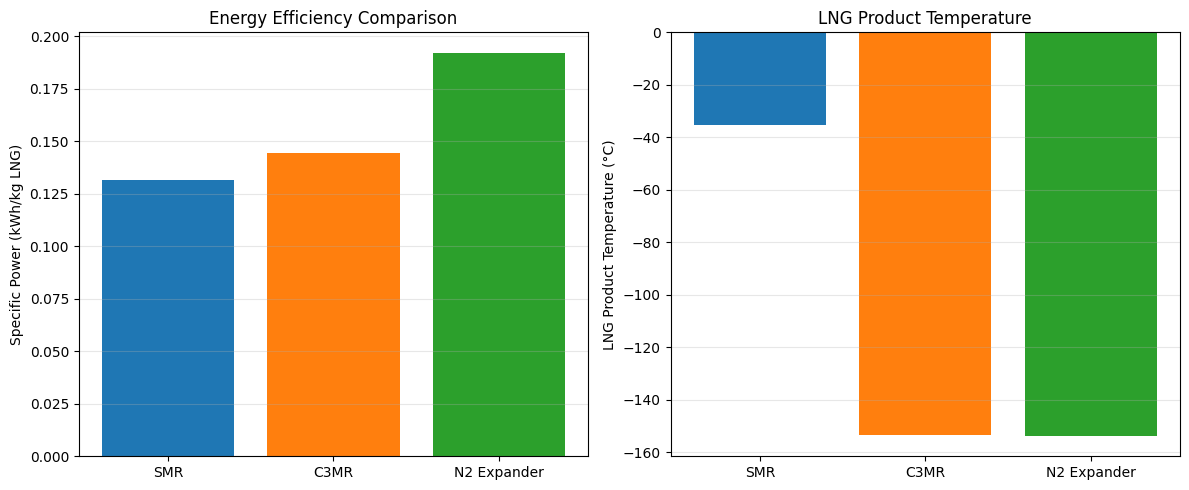

Figure saved: lng_cycle_comparison.png


In [5]:
# Compare the three cycles
smr_specific = (mr_comp1.getPower('kW') + mr_comp2.getPower('kW')) / 100000.0
c3mr_specific = total_c3mr / 200000.0
n2_specific = net_power / 80000.0

smr_lng_t = lng_valve.getOutletStream().getTemperature() - 273.15
c3mr_lng_t = lng_valve2.getOutletStream().getTemperature() - 273.15
n2_lng_t = lng_valve3.getOutletStream().getTemperature() - 273.15

comparison = pd.DataFrame({
    'Cycle': ['SMR', 'C3MR', 'N2 Expander'],
    'NG Feed Rate (t/h)': [100, 200, 80],
    'LNG Temp (°C)': [round(smr_lng_t, 1), round(c3mr_lng_t, 1), round(n2_lng_t, 1)],
    'Total Power (kW)': [
        round(mr_comp1.getPower('kW') + mr_comp2.getPower('kW'), 0),
        round(total_c3mr, 0),
        round(net_power, 0)
    ],
    'Specific Power (kWh/kg)': [round(smr_specific, 3), round(c3mr_specific, 3), round(n2_specific, 3)],
})
print(comparison.to_string(index=False))

# --- Plot Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cycles = ['SMR', 'C3MR', 'N2 Expander']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Specific power comparison
axes[0].bar(cycles, [smr_specific, c3mr_specific, n2_specific], color=colors)
axes[0].set_ylabel('Specific Power (kWh/kg LNG)')
axes[0].set_title('Energy Efficiency Comparison')
axes[0].grid(axis='y', alpha=0.3)

# LNG temperature achieved
axes[1].bar(cycles, [smr_lng_t, c3mr_lng_t, n2_lng_t], color=colors)
axes[1].set_ylabel('LNG Product Temperature (°C)')
axes[1].set_title('LNG Product Temperature')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('lng_cycle_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: lng_cycle_comparison.png')

## MR Composition Sensitivity Study

Let's study how the mixed refrigerant composition affects the liquefaction efficiency.

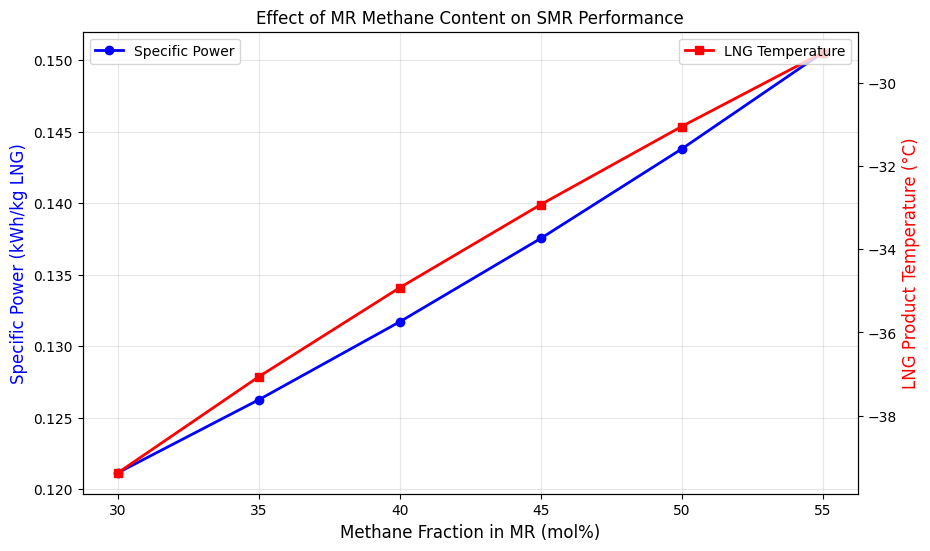

Figure saved: mr_composition_sensitivity.png


In [6]:
# Sensitivity: vary methane fraction in MR, keep others proportional
ch4_fractions = [30, 35, 40, 45, 50, 55]
sp_powers = []
lng_temps = []

for ch4_frac in ch4_fractions:
    remaining = 100.0 - 5.0 - ch4_frac  # 5% nitrogen fixed
    c2_frac = remaining * 0.636  # maintain ethane:propane ratio
    c3_frac = remaining * 0.364

    mr_f = SystemSrkEos(273.15 - 40.0, 3.0)
    mr_f.addComponent('nitrogen', 5.0)
    mr_f.addComponent('methane', float(ch4_frac))
    mr_f.addComponent('ethane', c2_frac)
    mr_f.addComponent('propane', c3_frac)
    mr_f.setMixingRule('classic')

    mr_s = Stream('MR', mr_f)
    mr_s.setFlowRate(180000.0, 'kg/hr')
    mr_s.setTemperature(-40.0, 'C')
    mr_s.setPressure(3.0, 'bara')

    ng_f = SystemSrkEos(273.15 + 25.0, 60.0)
    ng_f.addComponent('methane', 90.0)
    ng_f.addComponent('ethane', 6.0)
    ng_f.addComponent('propane', 3.0)
    ng_f.addComponent('n-butane', 1.0)
    ng_f.setMixingRule('classic')

    ng_s = Stream('NG', ng_f)
    ng_s.setFlowRate(100000.0, 'kg/hr')
    ng_s.setTemperature(25.0, 'C')
    ng_s.setPressure(60.0, 'bara')

    p = ProcessSystem()
    p.add(ng_s)
    p.add(mr_s)

    c1 = Compressor('C1', mr_s)
    c1.setOutletPressure(10.0)
    c1.setIsentropicEfficiency(0.75)
    p.add(c1)

    ic1 = Cooler('IC1', c1.getOutletStream())
    ic1.setOutTemperature(273.15 + 30.0)
    p.add(ic1)

    c2 = Compressor('C2', ic1.getOutletStream())
    c2.setOutletPressure(30.0)
    c2.setIsentropicEfficiency(0.75)
    p.add(c2)

    ac1 = Cooler('AC1', c2.getOutletStream())
    ac1.setOutTemperature(273.15 + 30.0)
    p.add(ac1)

    jt = ThrottlingValve('JT', ac1.getOutletStream())
    jt.setOutletPressure(3.0)
    p.add(jt)

    hx = HeatExchanger('HX', ng_s, jt.getOutletStream())
    hx.setUAvalue(500000.0)
    p.add(hx)

    lv = ThrottlingValve('LV', hx.getOutStream(0))
    lv.setOutletPressure(1.2)
    p.add(lv)

    p.run()

    total_pw = c1.getPower('kW') + c2.getPower('kW')
    sp_powers.append(total_pw / 100000.0)
    lng_temps.append(lv.getOutletStream().getTemperature() - 273.15)

# Plot sensitivity
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(ch4_fractions, sp_powers, 'b-o', linewidth=2, label='Specific Power')
ax2.plot(ch4_fractions, lng_temps, 'r-s', linewidth=2, label='LNG Temperature')

ax1.set_xlabel('Methane Fraction in MR (mol%)', fontsize=12)
ax1.set_ylabel('Specific Power (kWh/kg LNG)', color='blue', fontsize=12)
ax2.set_ylabel('LNG Product Temperature (°C)', color='red', fontsize=12)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(alpha=0.3)
plt.title('Effect of MR Methane Content on SMR Performance')
plt.savefig('mr_composition_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: mr_composition_sensitivity.png')

## Summary

This notebook demonstrated simulation of three LNG liquefaction cycles using NeqSim:

- **SMR** — simplest design, moderate efficiency, suitable for small-scale LNG
- **C3MR** — most efficient, industry standard for baseload LNG plants
- **N₂ Expander** — safest (inert refrigerant), lower efficiency, ideal for offshore

### Next Steps
- Optimize MR composition for minimum specific power
- Add multi-stream heat exchanger with composite curves
- Model heavy hydrocarbon removal before liquefaction
- Study effect of ambient temperature on cycle performance